### Util code to run and debug flare

In [1]:
import time
import os
import numpy as np
from pathlib import Path
from gpytoolbox import remesh_botsch
import torch
from tqdm.notebook import tqdm
from types import SimpleNamespace

In [2]:
import sys
sys.path.append("../external/flare_adl4cv") 
from flame.FLAME import FLAME
from flare.core import (
    Mesh, Renderer
)
from flare.losses import *
from flare.modules import (
    NeuralShader, get_deformer_network, Displacement
)
from flare.utils import (
    AABB, read_mesh, write_mesh,
    visualize_training,
    make_dirs, set_defaults_finetune
)
import nvdiffrec.render.light as light
from flare.dataset import DatasetLoader, dataset_util
from flare.dataset import *
from flare.metrics import metrics
import nvdiffrec.render.light as light


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/hleonhard/miniconda3/envs/flare/lib/python3.9/site-packages/torch/utils/cpp_extension.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [3]:
config = {
    'config': None,
    'run_name': '001_test',
    'batch_size': 2,
    # path
    'input_dir': Path("/home/hleonhard/data/flare_subject_data/001"),
    'train_dir': ["MVI_1814", "MVI_1810"],
    'eval_dir': ["MVI_1812"],
    'working_dir': Path("/home/hleonhard/data/flare_train_setup"),
    'output_dir': Path("out"),
    # misc
    'sample_idx_ratio': 1,
    'device': 0,
    'finetune_color': False,
    # iters
    'iterations': 2000, 
    'final_iter': 1500,
    'upsample_iterations': [500],
    'save_frequency': 300,
    'visualization_frequency': 100,
    'visualization_views': [15, 25, 27, 21, 26],
    # 'downsample' default is set via set_defaults
    'downsample': False,
    'downsample_ratio': 0.03,
    'grad_scale': False, # Default for action='store_true' is False unless set otherwise
    # flame
    'decay_flame': [100],
    'flame_mask': False,
    # lr
    'lr_vertices': 1e-3,
    'lr_shader': 1e-3,
    'lr_deformer': 1e-3,
    # loss weights
    'weight_mask': 2.0,
    'weight_normal': 0.1,
    'weight_laplacian': 60.0,
    'weight_shading': 1.0,
    'weight_perceptual_loss': 0.1,
    'weight_albedo_regularization': 0.01,
    'weight_flame_regularization': 10.0,
    'weight_white_lgt_regularization': 1.0,
    'weight_roughness_regularization': 0.1,
    'weight_fresnel_coeff': 0.01,
    'r_mean': 0.500,
    # neural shader
    'fourier_features': 'positional',
    'activation': 'relu',
    'bsdf': 'pbr_shading',
    'deform_d_out': 128,
    'light_mlp_ch': 3,
    'light_mlp_dims': [64, 64],
    'material_mlp_dims': [128, 128, 128, 128, 128],
    'material_mlp_ch': 5,
    # ghostbone/train_deformer (defaults are set via set_defaults)
    'ghostbone': True,
    'train_deformer': True,
    'deform_dims': [128, 128, 128, 128]
}

config = SimpleNamespace(**config)

In [4]:
# Select the device
device = torch.device('cpu')
if torch.cuda.is_available() and config.device >= 0:
    device = torch.device(f'cuda:{config.device}')

In [5]:
print("loading train views...")
dataset_train = DatasetLoader(config, train_dir=config.train_dir, sample_ratio=config.sample_idx_ratio, pre_load=True)
dataset_val = DatasetLoader(config, train_dir=config.eval_dir, sample_ratio=24, pre_load=True)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=config.batch_size, collate_fn=dataset_train.collate, shuffle=True, drop_last=True)
view_indices = np.array(config.visualization_views).astype(int)
d_l = [dataset_val.__getitem__(idx) for idx in view_indices[2:]]
d_l.append(dataset_train.__getitem__(view_indices[0]))
d_l.append(dataset_train.__getitem__(view_indices[1]))
debug_views = dataset_val.collate(d_l)
del dataset_val

loading train views...
loaded 2903 views
loaded 76 views


In [6]:
### ============== load FLAME mesh ==============================
flame_path = "/home/hleonhard/adl4cv_ws25-26_Relightable-Avatars/external/flare_adl4cv/flame/FLAME2020/generic_model.pkl"
flame_shape = dataset_train.shape_params
FLAMEServer = FLAME(flame_path, n_shape=100, n_exp=50, shape_params=flame_shape).to(device)
## ============== canonical with mouth open (jaw pose 0.4) ==============================
FLAMEServer.canonical_exp = (dataset_train.get_mean_expression()).to(device)
FLAMEServer.canonical_pose = FLAMEServer.canonical_pose.to(device)
FLAMEServer.canonical_verts, FLAMEServer.canonical_pose_feature, FLAMEServer.canonical_transformations = \
    FLAMEServer(expression_params=FLAMEServer.canonical_exp, full_pose=FLAMEServer.canonical_pose)
if config.ghostbone:
    FLAMEServer.canonical_transformations = torch.cat([torch.eye(4).unsqueeze(0).unsqueeze(0).float().to(device), FLAMEServer.canonical_transformations], 1)
FLAMEServer.canonical_verts = FLAMEServer.canonical_verts.to(device)

creating the FLAME Decoder


In [7]:
run_name = config.run_name if config.run_name is not None else config.input_dir.parent.name
images_save_path, images_eval_save_path, meshes_save_path, shaders_save_path, experiment_dir = make_dirs(config, run_name, config.finetune_color)

In [8]:
print(f'Setup dirs \n{images_save_path}\n{images_eval_save_path}\n{meshes_save_path}\n{shaders_save_path}\n{experiment_dir}')

Setup dirs 
/home/hleonhard/data/flare_train_setup/out/001_test/stage_1/images
/home/hleonhard/data/flare_train_setup/out/001_test/images_evaluation
/home/hleonhard/data/flare_train_setup/out/001_test/stage_1/meshes
/home/hleonhard/data/flare_train_setup/out/001_test/stage_1/network_weights
/home/hleonhard/data/flare_train_setup/out/001_test


In [9]:
## ============== load mesh/train mesh ==============================
if config.finetune_color:
    mesh_path = experiment_dir / "stage_1" / "meshes" / f"mesh_latest.obj"
    print("loading mesh from:", mesh_path)
    flame_canonical_mesh = read_mesh(mesh_path, device=device)
    flame_canonical_mesh.compute_connectivity()
    flame_canonical_mesh.to(device)
else:
    if config.downsample:
        v_down, f_down = remesh_botsch(FLAMEServer.canonical_verts.squeeze(0).cpu().detach().numpy().astype(np.float64), 
                                                                FLAMEServer.faces_tensor.cpu().numpy().astype(np.int32), h=float(config.downsample_ratio))
        verts = np.ascontiguousarray(v_down)
        faces = np.ascontiguousarray(f_down)
        print("Downsampled:", verts.shape, faces.shape)
    else:
        verts = FLAMEServer.canonical_verts.squeeze(0)
        faces = FLAMEServer.faces_tensor
    flame_canonical_mesh: Mesh = None
    flame_canonical_mesh = Mesh(verts, faces, device=device)
    flame_canonical_mesh.compute_connectivity()
    write_mesh(Path(meshes_save_path / "init_mesh.obj"), flame_canonical_mesh.to('cpu'))

In [10]:
## ============== renderer ==============================
aabb = AABB(flame_canonical_mesh.vertices.cpu().numpy())
flame_mesh_aabb = [torch.min(flame_canonical_mesh.vertices, dim=0).values, torch.max(flame_canonical_mesh.vertices, dim=0).values]
renderer = Renderer(device=device)
renderer.set_near_far(dataset_train, torch.from_numpy(aabb.corners).to(device), epsilon=0.5)
channels_gbuffer = ['mask', 'position', 'normal', "canonical_position"]
print("Rasterizing:", channels_gbuffer)

renderer_visualization = Renderer(device=device)
renderer_visualization.set_near_far(dataset_train, torch.from_numpy(aabb.corners).to(device), epsilon=0.5)

Rasterizing: ['mask', 'position', 'normal', 'canonical_position']


In [11]:
# ==============================================================================================
# vertices
# ==============================================================================================
lr_vertices = config.lr_vertices
displacements = Displacement(vertices_shape=flame_canonical_mesh.vertices.shape)

displacements.to(device=device)
optimizer_vertices = torch.optim.Adam(list(displacements.parameters()), lr=lr_vertices)

In [12]:
# ==============================================================================================
# deformation 
# ==============================================================================================
if config.train_deformer:
    model_path = None
    print("=="*50)
    print("Training Deformer")
else:
    print("=="*50)
    print("Loading deformer network trained in the previous stage")
    config.weight_flame_regularization = 0.0
    model_path = Path(experiment_dir / "stage_1" / "network_weights" / f"deformer_latest.pt")
    assert os.path.exists(model_path)
deformer_net = get_deformer_network(FLAMEServer, model_path=model_path, train=config.train_deformer, d_in=3, dims=config.deform_dims, 
                                       weight_norm=True, multires=0, num_exp=50, aabb=flame_mesh_aabb, ghostbone=config.ghostbone, device=device)
if config.train_deformer:
    optimizer_deformer = torch.optim.Adam(list(deformer_net.parameters()), lr=config.lr_deformer)

Training Deformer


In [13]:
# ==============================================================================================
# shading
# ==============================================================================================
lgt = light.create_env_rnd()    
disentangle_network_params = {
    "material_mlp_ch": config.material_mlp_ch,
    "light_mlp_ch": config.light_mlp_ch,
    "material_mlp_dims": config.material_mlp_dims,
    "light_mlp_dims": config.light_mlp_dims
}
# Create the optimizer for the neural shader
shader = NeuralShader(fourier_features=config.fourier_features,
                      activation=config.activation,
                      last_activation=torch.nn.Sigmoid(), 
                      disentangle_network_params=disentangle_network_params,
                      bsdf=config.bsdf,
                      aabb=flame_mesh_aabb,
                      device=device)
params = list(shader.parameters()) 
if config.weight_albedo_regularization > 0:
    from robust_loss_pytorch.adaptive import AdaptiveLossFunction
    _adaptive = AdaptiveLossFunction(num_dims=4, float_dtype=np.float32, device=device)
    params += list(_adaptive.parameters()) ## need to train it
optimizer_shader = torch.optim.Adam(params, lr=config.lr_shader)

STAGE 1: Using positional encoding (NeRF) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [128, 128, 128, 128, 128], 'light_mlp_dims': [64, 64]}


In [14]:
# ==============================================================================================
# Loss Functions
# ==============================================================================================
# Initialize the loss weights and losses
loss_weights = {
    "mask": config.weight_mask,
    "normal": config.weight_normal,
    "laplacian": config.weight_laplacian,
    "shading": config.weight_shading,
    "perceptual_loss": config.weight_perceptual_loss,
    "albedo_regularization": config.weight_albedo_regularization,
    "roughness_regularization": config.weight_roughness_regularization,
    "white_light_regularization": config.weight_white_lgt_regularization,
    "fresnel_coeff": config.weight_fresnel_coeff
}
if config.train_deformer:
    loss_weights["flame_regularization"] = 1.0 # we use the weight directly in loss function
else:
    loss_weights["flame_regularization"] = 0.0
losses = {k: torch.tensor(0.0, device=device) for k in loss_weights}
print(loss_weights)
if loss_weights["perceptual_loss"] > 0.0:
    VGGloss = VGGPerceptualLoss().to(device) # is loaded from flare losses
print("=="*50)
shader.train()
if config.train_deformer:
    deformer_net.train()
displacements.train()
print("Batch Size:", config.batch_size)
print("=="*50)

{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.1, 'white_light_regularization': 1.0, 'fresnel_coeff': 0.01, 'flame_regularization': 1.0}


Batch Size: 2


In [15]:
# ==============================================================================================
# util func for evaluation
# ==============================================================================================
def run(args, mesh, views, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer, lgt):
    ## ============== deform ==============================     
    shapedirs, posedirs, lbs_weights = deformer_net.query_weights(mesh.vertices)
    eval_vertices = mesh.vertices
    batched_verts = eval_vertices.unsqueeze(0).repeat(views["img"].shape[0], 1, 1)

    _, pose_features, transformations = FLAMEServer(expression_params=views["flame_expression"], full_pose=views["flame_pose"])
    if args.ghostbone:
        transformations = torch.cat([torch.eye(4).unsqueeze(0).unsqueeze(0).expand(views["img"].shape[0], -1, -1, -1).float().to(device), transformations], 1)
    deformed_vertices = FLAMEServer.forward_pts_batch(pnts_c=batched_verts, betas=views["flame_expression"], transformations=transformations, pose_feature=pose_features, 
                                        shapedirs=shapedirs, posedirs=posedirs, lbs_weights=lbs_weights, dtype=torch.float32, map2_flame_original=True)

    d_normals = mesh.fetch_all_normals(deformed_vertices, mesh)
    ## ============== Rasterize ==============================
    gbuffers = renderer.render_batch(views["camera"], deformed_vertices.contiguous(), d_normals,
                        channels=channels_gbuffer, with_antialiasing=True, 
                        canonical_v=mesh.vertices, canonical_idx=mesh.indices)
    
    ## ============== predict color ==============================
    rgb_pred, cbuffers, gbuffer_mask = shader.shade(gbuffers, views, mesh, args.finetune_color, lgt)

    return rgb_pred, gbuffers, cbuffers

In [16]:
# ==============================================================================================
# T R A I N I N G
# ==============================================================================================
epochs = (config.iterations // len(dataloader_train)) + 1
iteration = 0
progress_bar = tqdm(range(epochs))
start = time.time()
for epoch in progress_bar:
    for iter_, views_subset in enumerate(dataloader_train):
        iteration += 1
        progress_bar.set_description(desc=f'Epoch {epoch}, Iter {iteration}')
        
        # ==============================================================================================
        # upsample + remesh + reduce lr + freeze if required
        # ==============================================================================================
        if iteration in config.upsample_iterations and not config.finetune_color:
            print("=="*50)
            print("Upsampling at iteration:", iteration)
            # Upsample the mesh by remeshing the surface with half the average edge length
            e0, e1 = mesh.edges.unbind(1)
            average_edge_length = torch.linalg.norm(canonical_offset_vertices[e0] - canonical_offset_vertices[e1], dim=-1).mean()
            v_upsampled, f_upsampled = remesh_botsch(canonical_offset_vertices.cpu().detach().numpy().astype(np.float64), 
                                                    mesh.indices.cpu().numpy().astype(np.int32), h=float(average_edge_length/1.5))
            v_upsampled = np.ascontiguousarray(v_upsampled)
            f_upsampled = np.ascontiguousarray(f_upsampled)
            flame_canonical_mesh = Mesh(v_upsampled, f_upsampled, device=device)
            flame_canonical_mesh.compute_connectivity()
            print("Vertices:", v_upsampled.shape)
            print("Faces:", f_upsampled.shape)
            del v_upsampled, f_upsampled
            if iteration == config.upsample_iterations[0]:
                lr_vertices *= 0.75
                # Adjust weights and step size
                loss_weights['laplacian'] *= 4
                loss_weights['normal'] *= 4
            print("laplacian weight", loss_weights['laplacian'])
            print("normal consistency weight", loss_weights['normal'])
            print("lr vertices", lr_vertices)
            displacements.register_parameter('vertex_offsets', torch.nn.Parameter(torch.zeros(flame_canonical_mesh.vertices.shape), requires_grad=True))
            displacements.canonical_vertices = flame_canonical_mesh.vertices
            displacements.vertices_shape = flame_canonical_mesh.vertices.shape
            displacements.to(device=device)
            optimizer_vertices = torch.optim.Adam(list(displacements.parameters()), lr=lr_vertices)
            print("=="*50)
        # ==============================================================================================
        # update/displace vertices
        # ==============================================================================================
        v_off = displacements()
        canonical_offset_vertices = flame_canonical_mesh.vertices + v_off
        mesh = flame_canonical_mesh.with_vertices(canonical_offset_vertices)
        # ==============================================================================================
        # deformation of canonical mesh
        # ==============================================================================================      
        shapedirs, posedirs, lbs_weights = deformer_net.query_weights(mesh.vertices)
        
        batched_verts = mesh.vertices.unsqueeze(0).repeat(config.batch_size, 1, 1)
        _, pose_features, transformations = FLAMEServer(expression_params=views_subset["flame_expression"], full_pose=views_subset["flame_pose"])
        if config.ghostbone:
            transformations = torch.cat([torch.eye(4).unsqueeze(0).unsqueeze(0).expand(config.batch_size, -1, -1, -1).float().to(device), transformations], 1)
        deformed_vertices = FLAMEServer.forward_pts_batch(pnts_c=batched_verts, betas=views_subset["flame_expression"], transformations=transformations, pose_feature=pose_features, 
                                            shapedirs=shapedirs, posedirs=posedirs, lbs_weights=lbs_weights, dtype=torch.float32, map2_flame_original=True)
        d_normals = mesh.fetch_all_normals(deformed_vertices, mesh)
        # ==============================================================================================
        # R A S T E R I Z A T I O N
        # ==============================================================================================
        gbuffers = renderer.render_batch(views_subset['camera'], deformed_vertices.contiguous(), d_normals, 
                                channels=channels_gbuffer, with_antialiasing=True, 
                                canonical_v=mesh.vertices, canonical_idx=mesh.indices) 
        
        # ==============================================================================================
        # loss function 
        # ==============================================================================================
        ## ============== geometry regularization ==============================
        losses['normal'] = normal_consistency_loss(mesh)
        losses['laplacian'] = laplacian_loss(mesh)
        ## ============== color + regularization for color ==============================
        pred_color_masked, cbuffers, gbuffer_mask = shader.shade(gbuffers, views_subset, mesh, config.finetune_color, lgt)
        losses['shading'], pred_color, tonemapped_colors = shading_loss_batch(pred_color_masked, views_subset, config.batch_size)
        losses['perceptual_loss'] = VGGloss(tonemapped_colors[0], tonemapped_colors[1], iteration)
        
        losses['mask'] = mask_loss(views_subset["mask"], gbuffer_mask)
        ## ======= regularization color ========
        losses['albedo_regularization'] = albedo_regularization(_adaptive, shader, mesh, device, displacements, iteration)
        losses['white_light_regularization'] = white_light(cbuffers)
        losses['roughness_regularization'] = roughness_regularization(cbuffers["roughness"], views_subset["skin_mask"], views_subset["mask"], r_mean=config.r_mean)
        losses["fresnel_coeff"] = spec_intensity_regularization(cbuffers["ko"], views_subset["skin_mask"], views_subset["mask"])
        
        ## ============== flame regularization ==============================
        if loss_weights['flame_regularization'] > 0:
            losses['flame_regularization'], gt_nn = flame_regularization(FLAMEServer, lbs_weights, shapedirs, posedirs, mesh.vertices, config.ghostbone, 
                                                                  iteration, config.flame_mask, views_subset=views_subset, gbuffer=gbuffers, 
                                                                  weight_lbs=config.weight_flame_regularization)
        
            if iteration in config.decay_flame:
                print("Decaying flame regularization")
                loss_weights['flame_regularization'] *= 0.5
        loss = torch.tensor(0., device=device) 
        for k, v in losses.items():
            loss += v * loss_weights[k]
        # ==============================================================================================
        # Optimizer step
        # ==============================================================================================
        optimizer_shader.zero_grad()
        optimizer_vertices.zero_grad()
        if config.train_deformer:
            optimizer_deformer.zero_grad()
        loss.backward()
        torch.cuda.synchronize()
        ### increase the gradients of positional encoding following tinycudnn
        if config.grad_scale and config.fourier_features == "hashgrid":
            shader.fourier_feature_transform.params.grad /= 8.0
        optimizer_shader.step()
        optimizer_vertices.step()
        if config.train_deformer:
            optimizer_deformer.step()
        progress_bar.set_postfix({'loss': loss.detach().cpu().item()})
        # ==============================================================================================
        # warning: check if light mlp diverged
        # ==============================================================================================
        '''
        We do not use an activation function for the output layer of light MLP because we are learning in sRGB space where the values 
        are not restricted between 0 and 1. As a result, the light MLP diverges sometimes and predicts only zero values. 
        Hence, we have included the try and catch block to automatically restart the training during this case. 
        '''
        if iteration == 100:
            convert_uint = lambda x: torch.from_numpy(np.clip(np.rint(dataset_util.rgb_to_srgb(x).detach().cpu().numpy() * 255.0), 0, 255).astype(np.uint8)).to(device)
            try:
                diffuse_shading = convert_uint(cbuffers["shading"])
                specular_shading = convert_uint(cbuffers["specu"])
                if torch.count_nonzero(diffuse_shading) == 0 or torch.count_nonzero(specular_shading) == 0:
                    raise ValueError("All values predicted from light MLP are zero")
            except ValueError as e:
                print(f"Error: {e}")
                raise  # Raise the exception to exit the current execution of main()
        
        # ==============================================================================================
        # V I S U A L I Z A T I O N S
        # ==============================================================================================
        if (config.visualization_frequency > 0) and (iteration == 1 or iteration % config.visualization_frequency == 0):
            with torch.no_grad():
                debug_rgb_pred, debug_gbuffer, debug_cbuffers = run(config, mesh, debug_views, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer, lgt)
                ## ============== visualize ==============================
                visualize_training(debug_rgb_pred, debug_cbuffers, debug_gbuffer, debug_views, images_save_path, iteration)
                del debug_gbuffer, debug_cbuffers
        ## ============== save intermediate ==============================
        if (config.save_frequency > 0) and (iteration == 1 or iteration % config.save_frequency == 0):
            with torch.no_grad():
                write_mesh(meshes_save_path / f"mesh_{iteration:06d}.obj", mesh.detach().to('cpu'))                                
                shader.save(shaders_save_path / f'shader_{iteration:06d}.pt')
                displacements.save(shaders_save_path / f'displacement_{iteration:06d}.pt')
                deformer_net.save(shaders_save_path / f'deformer_{iteration:06d}.pt')


  0%|          | 0/2 [00:00<?, ?it/s]

Using /home/hleonhard/.cache/torch_extensions/py39_cu116 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/hleonhard/.cache/torch_extensions/py39_cu116/renderutils_plugin/build.ninja...
Building extension module renderutils_plugin...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


ninja: no work to do.


Loading extension module renderutils_plugin...


Decaying flame regularization
Upsampling at iteration: 500
Vertices: (18036, 3)
Faces: (36032, 3)
laplacian weight 240.0
normal consistency weight 0.4
lr vertices 0.00075


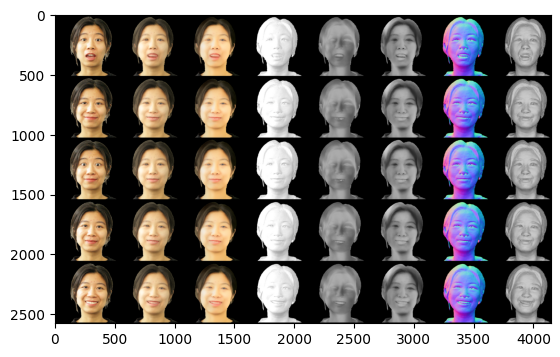

In [4]:
# visualize first and last grid
import matplotlib.pyplot as plt

img = plt.imread('/home/hleonhard/data/flare_train_setup/out/001_test/stage_1/images/grid/grid_2900.png')
plt.imshow(img)

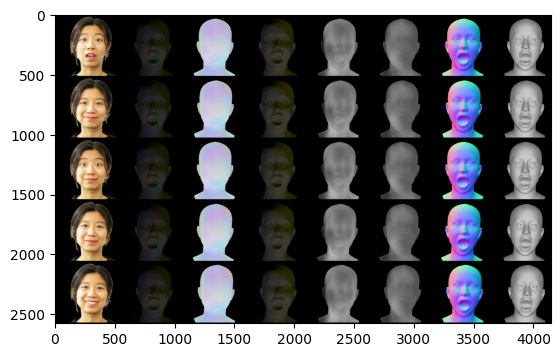

In [3]:
img = plt.imread('/home/hleonhard/data/flare_train_setup/out/001_test/stage_1/images/grid/grid_1.png')
plt.imshow(img)